# Solar Farms Defect Inspection

# Configuration

In [1]:
from pathlib import Path
from datetime import datetime
import cv2
import pandas as pd
import matplotlib.pyplot as plt


/home/hraj/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Project
PROJECT_ROOT = Path("/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection")

# Inputs
RGB_IMAGE = Path(
    "/home/hraj/Pictures"
    "/home/hraj/Workspace/Solor_defect_DB/Database/rgb_defect_detection_dataset/test/images/"
    "Clean-14-_jpg.rf.2a82138ca2c8bd6956848c89f592b292.jpg"
)

THERMAL_IMAGE = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Database/"
    "thermal_hotspot_detection_dataset/test/images/"
    "img-280-_JPG.rf.c7e2f0d3e6d9a81919854bf4bdd99b75.jpg"
)

# ONNX models
PANEL_MODEL = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/"
    "Experiment/runs/pannel_segment/runs/weights/best.onnx"
)

RGB_DEFECT_MODEL = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/"
    "Experiment/runs/rgb_defect_detection/baseline/runs/detect/baseline/weights/best.onnx"
)

THERMAL_MODEL = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/"
    "Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx"
)

# Output
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Inference
IMG_SIZE = 640
PANEL_CONFIDENCE = 0.35
RGB_DEFECT_CONFIDENCE = 0.05
THERMAL_CONFIDENCE = 0.35

# Inspection
INSPECTION_ID = "INS-001"

# Load ONNX Models

In [3]:
from ultralytics import YOLO

# Validate model files before loading.
for model_path in (PANEL_MODEL, RGB_DEFECT_MODEL, THERMAL_MODEL):
    if not model_path.is_file():
        raise FileNotFoundError(f"Model not found: {model_path}")

panel_model = YOLO(str(PANEL_MODEL))
rgb_defect_model = YOLO(str(RGB_DEFECT_MODEL))
thermal_model = YOLO(str(THERMAL_MODEL))

print("All ONNX models loaded successfully.")

All ONNX models loaded successfully.


# Load RGB + Thermal Input

In [4]:

if not RGB_IMAGE.is_file():
    raise FileNotFoundError(
        f"RGB image not found: {RGB_IMAGE}"
    )

if not THERMAL_IMAGE.is_file():
    raise FileNotFoundError(
        f"Thermal image not found: {THERMAL_IMAGE}"
    )

rgb_image = cv2.imread(str(RGB_IMAGE))
thermal_image = cv2.imread(str(THERMAL_IMAGE))

if rgb_image is None:
    raise ValueError(
        f"Unable to read RGB image: {RGB_IMAGE}"
    )

if thermal_image is None:
    raise ValueError(
        f"Unable to read thermal image: {THERMAL_IMAGE}"
    )

print("Input images loaded successfully.")

print(
    f"RGB     : {RGB_IMAGE.name} | "
    f"shape={rgb_image.shape}"
)

print(
    f"Thermal : {THERMAL_IMAGE.name} | "
    f"shape={thermal_image.shape}"
)

FileNotFoundError: RGB image not found: /home/hraj/Pictures/home/hraj/Workspace/Solor_defect_DB/Database/rgb_defect_detection_dataset/test/images/Clean-14-_jpg.rf.2a82138ca2c8bd6956848c89f592b292.jpg

# RGB Panel Segmentation

In [ ]:
panel_results = panel_model.predict(
    source=rgb_image,
    imgsz=IMG_SIZE,
    conf=PANEL_CONFIDENCE,
    verbose=False
)

panel_result = panel_results[0]

panels = []

if panel_result.boxes is not None:

    for i, box in enumerate(panel_result.boxes):

        confidence = float(box.conf[0].cpu().numpy())

        bbox = (
            box.xyxy[0]
            .cpu()
            .numpy()
            .tolist()
        )

        panels.append({
            "panel_id": f"P{i + 1:03d}",
            "bbox": bbox,
            "confidence": confidence,
        })


print(f"Panels detected: {len(panels)}")

for panel in panels:

    print(
        f"{panel['panel_id']} | "
        f"confidence={panel['confidence']:.3f} | "
        f"bbox={panel['bbox']}"
    )

Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/pannel_segment/runs/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Panels detected: 22
P001 | confidence=0.875 | bbox=[372.1737976074219, 666.0060424804688, 1023.2245483398438, 941.0]
P002 | confidence=0.852 | bbox=[0.0, 321.3453063964844, 168.5326385498047, 484.11309814453125]
P003 | confidence=0.843 | bbox=[0.6584866642951965, 516.8504638671875, 77.63483428955078, 788.6964721679688]
P004 | confidence=0.811 | bbox=[142.64051818847656, 808.7708129882812, 371.0942687988281, 941.0]
P005 | confidence=0.800 | bbox=[1013.6015014648438, 766.248779296875, 1372.9991455078125, 941.0]
P006 | confidence=0.783 | bbox=[0.5098851323127747, 863.6179809570312, 137.9672393798828, 941.0]
P007 | confidence=0.768 | bbox=[94.2947998046875, 105.19330596923828, 304.9949645996094, 213.7019805908203]
P008 | confidence=0.731 | bbox=[465.2473449707031, 259.83587646484375, 765.7636108

# RGB Defect Detection

In [ ]:
rgb_results = rgb_defect_model.predict(
    source=rgb_image,
    imgsz=IMG_SIZE,
    conf=RGB_DEFECT_CONFIDENCE,
    verbose=False
)

rgb_result = rgb_results[0]

rgb_defects = []

if rgb_result.boxes is not None:

    for i, box in enumerate(rgb_result.boxes):

        class_id = int(
            box.cls[0].cpu().numpy()
        )

        confidence = float(
            box.conf[0].cpu().numpy()
        )

        bbox = (
            box.xyxy[0]
            .cpu()
            .numpy()
            .tolist()
        )

        rgb_defects.append({
            "defect_id": f"RGB_D{i + 1:03d}",
            "class_name": rgb_result.names[class_id],
            "confidence": confidence,
            "bbox": bbox,
        })

print(f"RGB defects detected: {len(rgb_defects)}")

for defect in rgb_defects:

    print(
        f"{defect['defect_id']} | "
        f"{defect['class_name']} | "
        f"{defect['confidence']:.3f} | "
        f"bbox={defect['bbox']}"
    )

Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/detect/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
RGB defects detected: 14
RGB_D001 | bird-drop | 0.191 | bbox=[372.8697814941406, 87.38707733154297, 519.04541015625, 137.3487548828125]
RGB_D002 | snow-capped | 0.179 | bbox=[17.980709075927734, 0.0, 1671.223388671875, 12.680048942565918]
RGB_D003 | bird-drop | 0.154 | bbox=[1027.2052001953125, 676.8333129882812, 1087.4119873046875, 721.196044921875]
RGB_D004 | bird-drop | 0.135 | bbox=[0.0, 289.2961120605469, 1671.577392578125, 941.0]
RGB_D005 | bird-drop | 0.128 | bbox=[0.0, 36.29922103881836, 1672.0, 775.583740234375]
RGB_D006 | bird-drop | 0.118 | bbox=[557.364013671875, 574.271240234375, 596.9879150390625, 605.6201171875]
RGB_D007 | bird-drop | 0.083 | bbox=[0.0, 504.9201354980469, 1655.5635986328125, 941.0]
RGB_D008 | clean | 0.082 | bbox=[7.8084793090820

In [ ]:
rgb_raw_results = rgb_defect_model.predict(
    source=rgb_image,
    imgsz=IMG_SIZE,
    conf=0.001,       # deliberately very low
    verbose=False
)

rgb_raw_result = rgb_raw_results[0]

print("Number of raw detections:",
      len(rgb_raw_result.boxes) if rgb_raw_result.boxes is not None else 0)

if rgb_raw_result.boxes is not None:
    for i, box in enumerate(rgb_raw_result.boxes):
        class_id = int(box.cls[0].cpu().numpy())
        confidence = float(box.conf[0].cpu().numpy())
        bbox = box.xyxy[0].cpu().numpy().tolist()

        print(
            f"{i+1:02d} | "
            f"class={rgb_raw_result.names[class_id]} | "
            f"confidence={confidence:.4f} | "
            f"bbox={bbox}"
        )

Number of raw detections: 300
01 | class=bird-drop | confidence=0.1909 | bbox=[372.8697814941406, 87.38707733154297, 519.04541015625, 137.3487548828125]
02 | class=snow-capped | confidence=0.1785 | bbox=[17.980709075927734, 0.0, 1671.223388671875, 12.680048942565918]
03 | class=bird-drop | confidence=0.1545 | bbox=[1027.2052001953125, 676.8333129882812, 1087.4119873046875, 721.196044921875]
04 | class=bird-drop | confidence=0.1347 | bbox=[0.0, 289.2961120605469, 1671.577392578125, 941.0]
05 | class=bird-drop | confidence=0.1284 | bbox=[0.0, 36.29922103881836, 1672.0, 775.583740234375]
06 | class=bird-drop | confidence=0.1177 | bbox=[557.364013671875, 574.271240234375, 596.9879150390625, 605.6201171875]
07 | class=bird-drop | confidence=0.0832 | bbox=[0.0, 504.9201354980469, 1655.5635986328125, 941.0]
08 | class=clean | confidence=0.0816 | bbox=[7.808479309082031, 591.9804077148438, 1672.0, 941.0]
09 | class=bird-drop | confidence=0.0805 | bbox=[40.91916275024414, 10.963044166564941, 11

# Thermal Hotspot Detection

In [ ]:
thermal_hotspots = []

if len(panels) == 0:

    print(
        "No solar panels detected in RGB image."
    )

    print(
        "Thermal hotspot detection skipped."
    )

else:

    print(
        f"{len(panels)} solar panel(s) detected."
    )

    print(
        "Running thermal hotspot detection..."
    )

    thermal_results = thermal_model.predict(
        source=thermal_image,
        imgsz=IMG_SIZE,
        conf=THERMAL_CONFIDENCE,
        verbose=False
    )

    thermal_result = thermal_results[0]

    if thermal_result.boxes is not None:

        for i, box in enumerate(
            thermal_result.boxes
        ):

            class_id = int(
                box.cls[0].cpu().numpy()
            )

            confidence = float(
                box.conf[0].cpu().numpy()
            )

            bbox = (
                box.xyxy[0]
                .cpu()
                .numpy()
                .tolist()
            )

            thermal_hotspots.append({
                "hotspot_id": f"TH{i + 1:03d}",
                "class_name": thermal_result.names[class_id],
                "confidence": confidence,
                "bbox": bbox,
            })

    print(
        f"Thermal hotspots detected: "
        f"{len(thermal_hotspots)}"
    )

    for hotspot in thermal_hotspots:

        print(
            f"{hotspot['hotspot_id']} | "
            f"{hotspot['class_name']} | "
            f"{hotspot['confidence']:.3f} | "
            f"bbox={hotspot['bbox']}"
        )

22 solar panel(s) detected.
Running thermal hotspot detection...
Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Thermal hotspots detected: 3
TH001 | hotspot | 0.575 | bbox=[39.736610412597656, 63.302433013916016, 46.177574157714844, 70.2887954711914]
TH002 | hotspot | 0.455 | bbox=[52.23600769042969, 62.433311462402344, 58.20124053955078, 68.76548767089844]
TH003 | hotspot | 0.366 | bbox=[195.06570434570312, 98.90576934814453, 201.14407348632812, 106.35555267333984]


# Panel Association

In [ ]:
def bbox_center(bbox):
    x1, y1, x2, y2 = bbox
    return (
        (x1 + x2) / 2,
        (y1 + y2) / 2
    )


def point_inside_bbox(point, bbox):
    x, y = point
    x1, y1, x2, y2 = bbox

    return (
        x1 <= x <= x2
        and
        y1 <= y <= y2
    )


for defect in rgb_defects:

    defect_center = bbox_center(
        defect["bbox"]
    )

    defect["panel_id"] = None

    for panel in panels:

        if point_inside_bbox(
            defect_center,
            panel["bbox"]
        ):
            defect["panel_id"] = panel["panel_id"]
            break


print("RGB defect → panel association")

for defect in rgb_defects:

    print(
        f"{defect['defect_id']} | "
        f"{defect['class_name']} | "
        f"confidence={defect['confidence']:.3f} | "
        f"panel={defect['panel_id']}"
    )

RGB defect → panel association
RGB_D001 | bird-drop | confidence=0.191 | panel=None
RGB_D002 | snow-capped | confidence=0.179 | panel=None
RGB_D003 | bird-drop | confidence=0.154 | panel=P011
RGB_D004 | bird-drop | confidence=0.135 | panel=P010
RGB_D005 | bird-drop | confidence=0.128 | panel=P020
RGB_D006 | bird-drop | confidence=0.118 | panel=P010
RGB_D007 | bird-drop | confidence=0.083 | panel=P001
RGB_D008 | clean | confidence=0.082 | panel=P001
RGB_D009 | bird-drop | confidence=0.080 | panel=P013
RGB_D010 | bird-drop | confidence=0.059 | panel=P011
RGB_D011 | bird-drop | confidence=0.054 | panel=None
RGB_D012 | bird-drop | confidence=0.054 | panel=P018
RGB_D013 | bird-drop | confidence=0.053 | panel=P019
RGB_D014 | bird-drop | confidence=0.051 | panel=None


# Panel-Level Inspection Records

The final report is panel-level. Each row answers: which panel, what RGB finding, what thermal finding, which sensing modality provided evidence, and whether the panel requires inspection.

In [ ]:
inspection_records = []

for panel in panels:

    panel_id = panel["panel_id"]

    # Find RGB defects associated with this panel
    panel_rgb_defects = [
        defect
        for defect in rgb_defects
        if defect.get("panel_id") == panel_id
    ]

    # RGB finding
    if panel_rgb_defects:
        rgb_finding = ", ".join(
            defect["class_name"]
            for defect in panel_rgb_defects
        )

        rgb_confidence = max(
            defect["confidence"]
            for defect in panel_rgb_defects
        )
    else:
        rgb_finding = None
        rgb_confidence = None

    # At this stage thermal findings are NOT associated
    # with RGB panels because the images are independent.
    thermal_finding = None
    thermal_confidence = None

    # Determine status from RGB evidence only
    if rgb_finding is not None:
        status = "Require Inspection"
        evidence = "RGB"
    else:
        status = "No RGB Defect Detected"
        evidence = "None"

    inspection_records.append({
        "Panel ID": panel_id,
        "RGB Finding": rgb_finding,
        "RGB Confidence": rgb_confidence,
        "Thermal Finding": thermal_finding,
        "Thermal Confidence": thermal_confidence,
        "Evidence": evidence,
        "Status": status
    })


print("Inspection records created:")
print("---------------------------")

for record in inspection_records:
    print(record)

Inspection records created:
---------------------------
{'Panel ID': 'P001', 'RGB Finding': 'bird-drop, clean', 'RGB Confidence': 0.08319041132926941, 'Thermal Finding': None, 'Thermal Confidence': None, 'Evidence': 'RGB', 'Status': 'Require Inspection'}
{'Panel ID': 'P002', 'RGB Finding': None, 'RGB Confidence': None, 'Thermal Finding': None, 'Thermal Confidence': None, 'Evidence': 'None', 'Status': 'No RGB Defect Detected'}
{'Panel ID': 'P003', 'RGB Finding': None, 'RGB Confidence': None, 'Thermal Finding': None, 'Thermal Confidence': None, 'Evidence': 'None', 'Status': 'No RGB Defect Detected'}
{'Panel ID': 'P004', 'RGB Finding': None, 'RGB Confidence': None, 'Thermal Finding': None, 'Thermal Confidence': None, 'Evidence': 'None', 'Status': 'No RGB Defect Detected'}
{'Panel ID': 'P005', 'RGB Finding': None, 'RGB Confidence': None, 'Thermal Finding': None, 'Thermal Confidence': None, 'Evidence': 'None', 'Status': 'No RGB Defect Detected'}
{'Panel ID': 'P006', 'RGB Finding': None, 'RG

In [ ]:
inspection_df = pd.DataFrame(inspection_records)

inspection_df

,Panel ID,RGB Finding,RGB Confidence,Thermal Finding,Thermal Confidence,Evidence,Status
0,P001,"bird-drop, clean",0.083190,None,None,RGB,Require Inspection
1,P002,None,NaN,None,None,None,No RGB Defect Detected
2,P003,None,NaN,None,None,None,No RGB Defect Detected
3,P004,None,NaN,None,None,None,No RGB Defect Detected
4,P005,None,NaN,None,None,None,No RGB Defect Detected
5,P006,None,NaN,None,None,None,No RGB Defect Detected
6,P007,None,NaN,None,None,None,No RGB Defect Detected
7,P008,None,NaN,None,None,None,No RGB Defect Detected
8,P009,None,NaN,None,None,None,No RGB Defect Detected
9,P010,"bird-drop, bird-drop",0.134721,None,None,RGB,Require Inspection


In [ ]:
inspection_df.insert(
    0,
    "Inspection ID",
    INSPECTION_ID
)

inspection_df.insert(
    1,
    "Date / Time",
    datetime.now().strftime("%d-%m-%Y %H:%M:%S")
)

inspection_df

,Inspection ID,Date / Time,Panel ID,RGB Finding,RGB Confidence,Thermal Finding,Thermal Confidence,Evidence,Status
0,INS-001,25-09-2026 12:43:42,P001,"bird-drop, clean",0.083190,None,None,RGB,Require Inspection
1,INS-001,25-09-2026 12:43:42,P002,None,NaN,None,None,None,No RGB Defect Detected
2,INS-001,25-09-2026 12:43:42,P003,None,NaN,None,None,None,No RGB Defect Detected
3,INS-001,25-09-2026 12:43:42,P004,None,NaN,None,None,None,No RGB Defect Detected
4,INS-001,25-09-2026 12:43:42,P005,None,NaN,None,None,None,No RGB Defect Detected
5,INS-001,25-09-2026 12:43:42,P006,None,NaN,None,None,None,No RGB Defect Detected
6,INS-001,25-09-2026 12:43:42,P007,None,NaN,None,None,None,No RGB Defect Detected
7,INS-001,25-09-2026 12:43:42,P008,None,NaN,None,None,None,No RGB Defect Detected
8,INS-001,25-09-2026 12:43:42,P009,None,NaN,None,None,None,No RGB Defect Detected
9,INS-001,25-09-2026 12:43:42,P010,"bird-drop, bird-drop",0.134721,None,None,RGB,Require Inspection


# Visualization

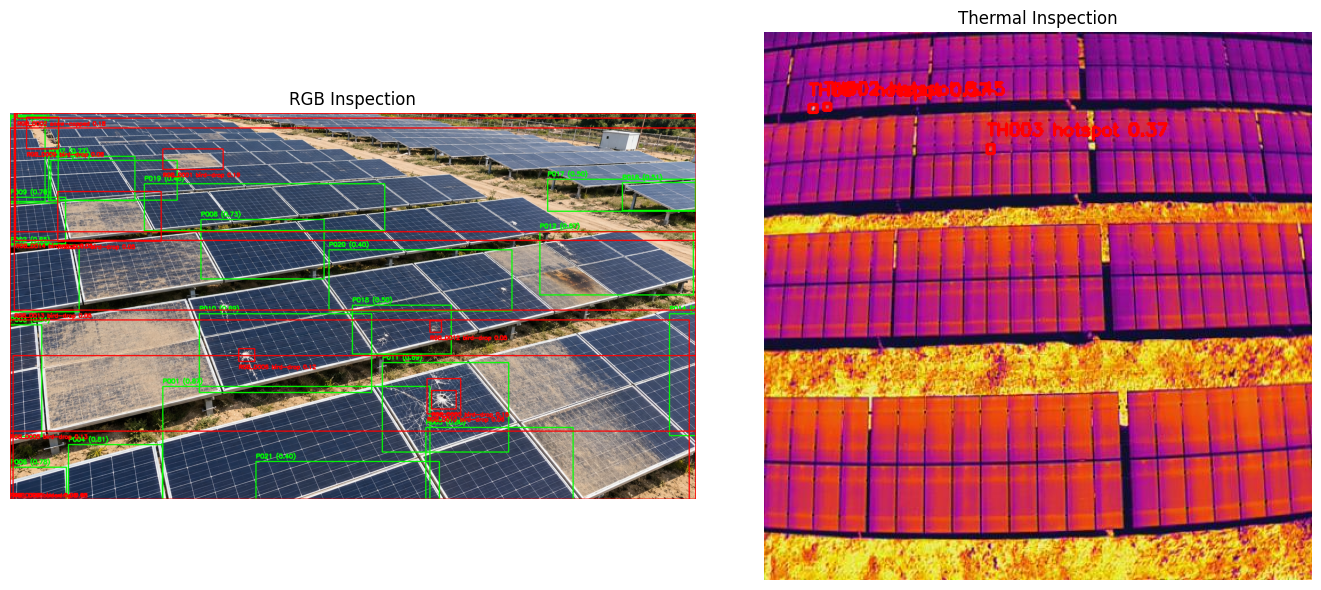

In [ ]:
rgb_vis = rgb_image.copy()
thermal_vis = thermal_image.copy()


# Draw detected panels
for panel in panels:

    x1, y1, x2, y2 = map(int, panel["bbox"])

    cv2.rectangle(
        rgb_vis,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        rgb_vis,
        f"{panel['panel_id']} ({panel['confidence']:.2f})",
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        2
    )


# Draw RGB defects
for defect in rgb_defects:

    x1, y1, x2, y2 = map(int, defect["bbox"])

    cv2.rectangle(
        rgb_vis,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        2
    )

    label = (
        f"{defect['defect_id']} "
        f"{defect['class_name']} "
        f"{defect['confidence']:.2f}"
    )

    cv2.putText(
        rgb_vis,
        label,
        (x1, min(y2 + 18, rgb_vis.shape[0] - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 0, 255),
        2
    )

# Draw ONLY thermal detections on thermal image
for hotspot in thermal_hotspots:

    x1, y1, x2, y2 = map(int, hotspot["bbox"])

    cv2.rectangle(
        thermal_vis,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        2
    )

    label = (
        f"{hotspot['hotspot_id']} "
        f"{hotspot['class_name']} "
        f"{hotspot['confidence']:.2f}"
    )

    cv2.putText(
        thermal_vis,
        label,
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        2
    )
    
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(rgb_vis, cv2.COLOR_BGR2RGB))
plt.title("RGB Inspection")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(thermal_vis, cv2.COLOR_BGR2RGB))
plt.title("Thermal Inspection")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Step 11 — Save RGB and Thermal Visualizations

RGB_OUTPUT = OUTPUT_DIR / "rgb_inspection_result.jpg"
THERMAL_OUTPUT = OUTPUT_DIR / "thermal_inspection_result.jpg"

cv2.imwrite(
    str(RGB_OUTPUT),
    rgb_vis
)

cv2.imwrite(
    str(THERMAL_OUTPUT),
    thermal_vis
)

print("Visualization outputs saved:")
print(f"RGB     : {RGB_OUTPUT}")
print(f"Thermal : {THERMAL_OUTPUT}")

Visualization outputs saved:
RGB     : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/rgb_inspection_result.jpg
Thermal : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/thermal_inspection_result.jpg


# Inspection Report

In [ ]:
# Step 12 — Final Inspection Report

REPORT_PATH = OUTPUT_DIR / "inspection_report.xlsx"

inspection_df.to_excel(
    REPORT_PATH,
    index=False
)

print("Inspection report generated successfully.")
print(f"Report: {REPORT_PATH}")

Inspection report generated successfully.
Report: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/inspection_report.xlsx


In [ ]:
inspection_df

,Inspection ID,Date / Time,Panel ID,RGB Finding,RGB Confidence,Thermal Finding,Thermal Confidence,Evidence,Status
0,INS-001,25-09-2026 12:43:42,P001,"bird-drop, clean",0.083190,None,None,RGB,Require Inspection
1,INS-001,25-09-2026 12:43:42,P002,None,NaN,None,None,None,No RGB Defect Detected
2,INS-001,25-09-2026 12:43:42,P003,None,NaN,None,None,None,No RGB Defect Detected
3,INS-001,25-09-2026 12:43:42,P004,None,NaN,None,None,None,No RGB Defect Detected
4,INS-001,25-09-2026 12:43:42,P005,None,NaN,None,None,None,No RGB Defect Detected
5,INS-001,25-09-2026 12:43:42,P006,None,NaN,None,None,None,No RGB Defect Detected
6,INS-001,25-09-2026 12:43:42,P007,None,NaN,None,None,None,No RGB Defect Detected
7,INS-001,25-09-2026 12:43:42,P008,None,NaN,None,None,None,No RGB Defect Detected
8,INS-001,25-09-2026 12:43:42,P009,None,NaN,None,None,None,No RGB Defect Detected
9,INS-001,25-09-2026 12:43:42,P010,"bird-drop, bird-drop",0.134721,None,None,RGB,Require Inspection


In [ ]:
thermal_records = []

for hotspot in thermal_hotspots:

    thermal_records.append({
        "Inspection ID": INSPECTION_ID,
        "Date / Time": datetime.now().strftime("%d-%m-%Y %H:%M:%S"),
        "Thermal ID": hotspot["hotspot_id"],
        "Thermal Finding": hotspot["class_name"],
        "Thermal Confidence": hotspot["confidence"],
        "Evidence": "Thermal",
        "Status": "Require Inspection"
    })

thermal_df = pd.DataFrame(thermal_records)

thermal_df

,Inspection ID,Date / Time,Thermal ID,Thermal Finding,Thermal Confidence,Evidence,Status
0,INS-001,25-09-2026 12:46:50,TH001,hotspot,0.574683,Thermal,Require Inspection
1,INS-001,25-09-2026 12:46:50,TH002,hotspot,0.454948,Thermal,Require Inspection
2,INS-001,25-09-2026 12:46:50,TH003,hotspot,0.365808,Thermal,Require Inspection


In [ ]:
FINAL_REPORT_PATH = OUTPUT_DIR / "solar_inspection_report.xlsx"

with pd.ExcelWriter(
    FINAL_REPORT_PATH,
    engine="openpyxl"
) as writer:

    inspection_df.to_excel(
        writer,
        sheet_name="Panel Findings",
        index=False
    )

    thermal_df.to_excel(
        writer,
        sheet_name="Thermal Findings",
        index=False
    )

print("Final inspection report saved.")
print(f"Report: {FINAL_REPORT_PATH}")

Final inspection report saved.
Report: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/solar_inspection_report.xlsx


### Save Inspection Report

## Inspection Report Structure

**Inspection Information**
- Inspection ID
- Date / Time

**Panel Findings**
- Panel ID
- RGB Finding + Confidence
- Thermal Finding + Confidence
- Evidence — which sensing modality detected the problem
- Status — `Requires Inspection` or `No Finding`